In [21]:
import os
import torch
import sys
import numpy as np
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface_2 import WaterSurface
from optical.surface_2 import TransformWaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants, np_rgb_render

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Dataset = LoadDataset()
Dataset = LoadDataset(wo_ref_model_path="../../results/0610/☆2025-0612_23-09_refraction_previous_default/ply/point_cloud_14999.ply")
Dataset.set_iamge(80)

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


In [ ]:
t_m, t_q, t_s = TransformWaterSurface.apply(
    means, quats, scales, worldtocam,
    1.33, 0.0, True, True, "newton", 10, 1e-6, 1e-4, 
    True, "dPa_dP", "edges", 0.33, "real"
)

/home/taiki/try-papers/gsplat/optical/surface_2.py:163: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.n = torch.tensor(n, dtype=torch.float32, device=device, requires_grad=False)
/home/taiki/try-papers/gsplat/optical/surface_2.py:164: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.plane = torch.tensor(plane, dtype=torch.float32, device=device, requires_grad=False)


(-0.5, 799.5, 799.5, -0.5)

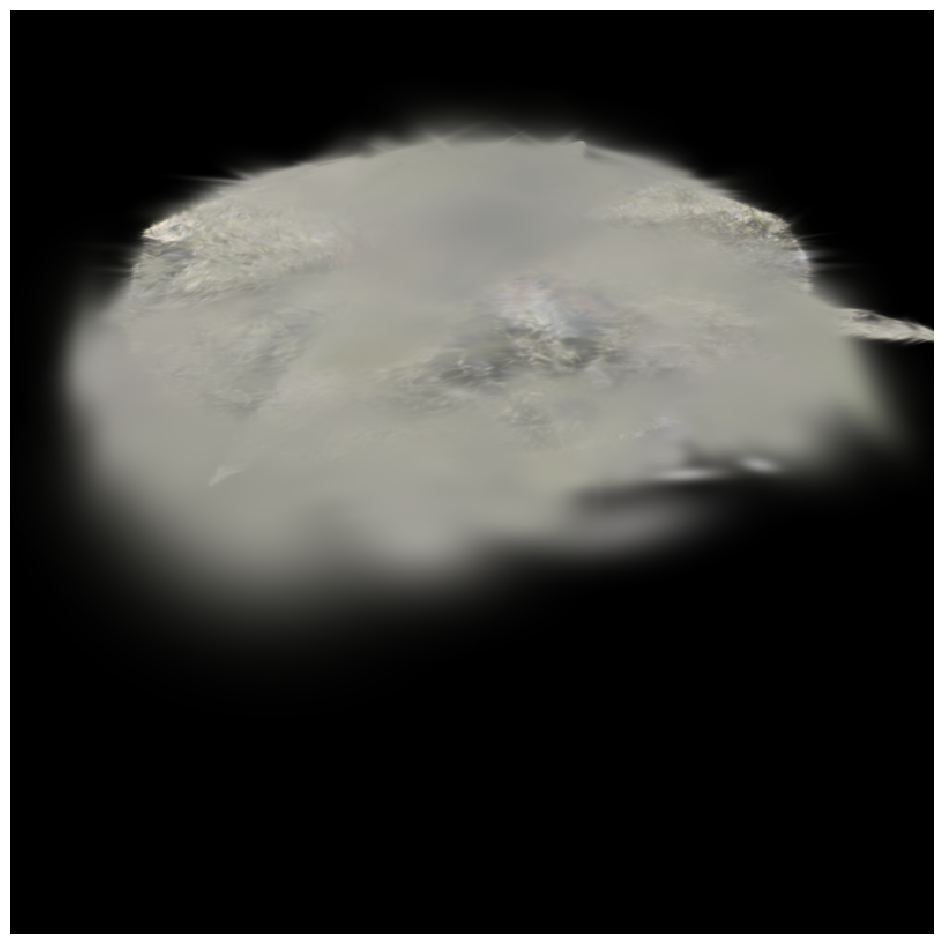

In [ ]:
render, _, _ = rasterization(
    t_m,
    t_q,
    t_s,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)

render_clamped = torch.clamp(render, 0.0, 1.0)
render_np = render_clamped.squeeze(0).detach().cpu().numpy()
render_np_uint8 = (render_np * 255).astype(np.uint8)

plt.imshow(render_np_uint8)
plt.axis("off")

In [26]:
WS = WaterSurface(
    means=means,
    quats=quats,
    scales=scales,
    cam_center=cam_center,
    n=n,
    plane=plane,
)

t_means = WS.transform_means()
# dPa_dP = WS.calc_dPa_dP()
dPa_dP = WS.calc_dPa_dP_with_minibatches()
t_quats = WS.transform_quats()

t_scales_edges_dev3 = WS.transform_scales(
    method_transform_scales="edges",
    coeff_transform_scales=1/3,
    scale_correct_space="real"
)




/home/taiki/try-papers/gsplat/optical/surface_2.py:163: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.n = torch.tensor(n, dtype=torch.float32, device=device, requires_grad=False)
/home/taiki/try-papers/gsplat/optical/surface_2.py:164: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.plane = torch.tensor(plane, dtype=torch.float32, device=device, requires_grad=False)


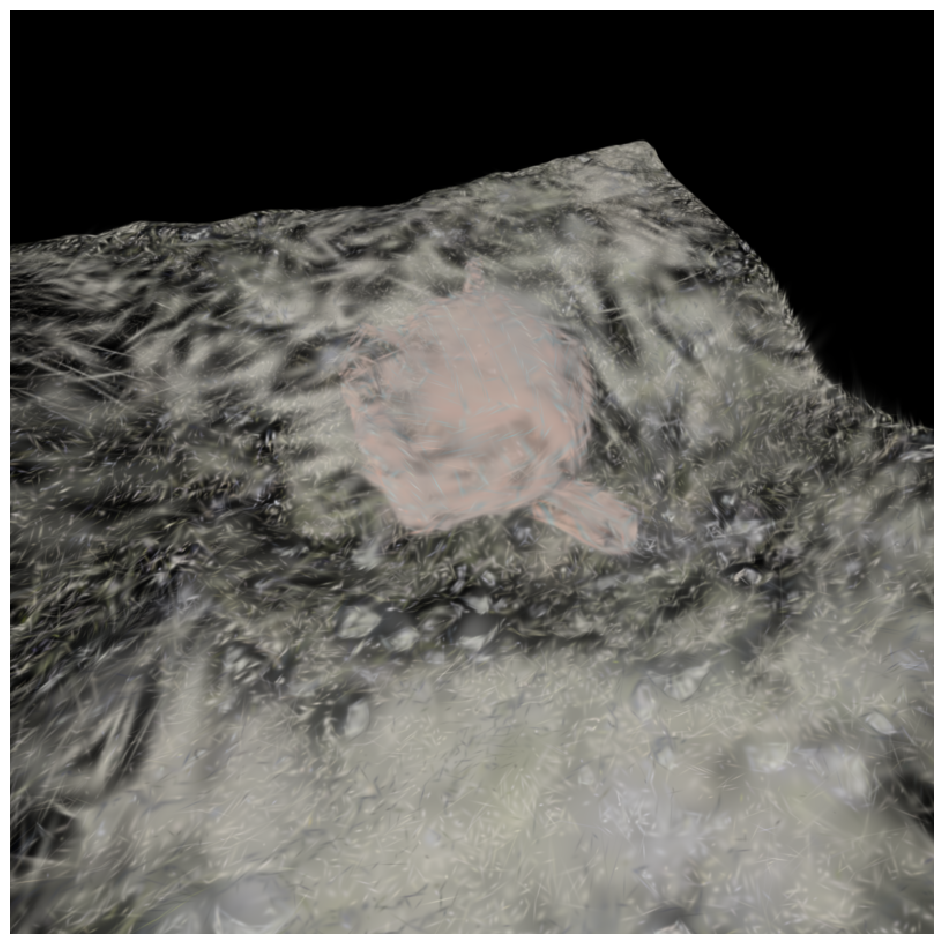

In [27]:
render2, _, _ = rasterization(
    t_means,
    t_quats,
    t_scales_edges_dev3,
    opacities,
    colors,
    worldtocam,
    K,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
render2_clamped = torch.clamp(render2, 0.0, 1.0)
render2_np = render2_clamped.squeeze(0).detach().cpu().numpy()
render2_np_uint8 = (render2_np * 255).astype(np.uint8)
plt.imshow(render2_np_uint8)
plt.axis("off")
plt.show()

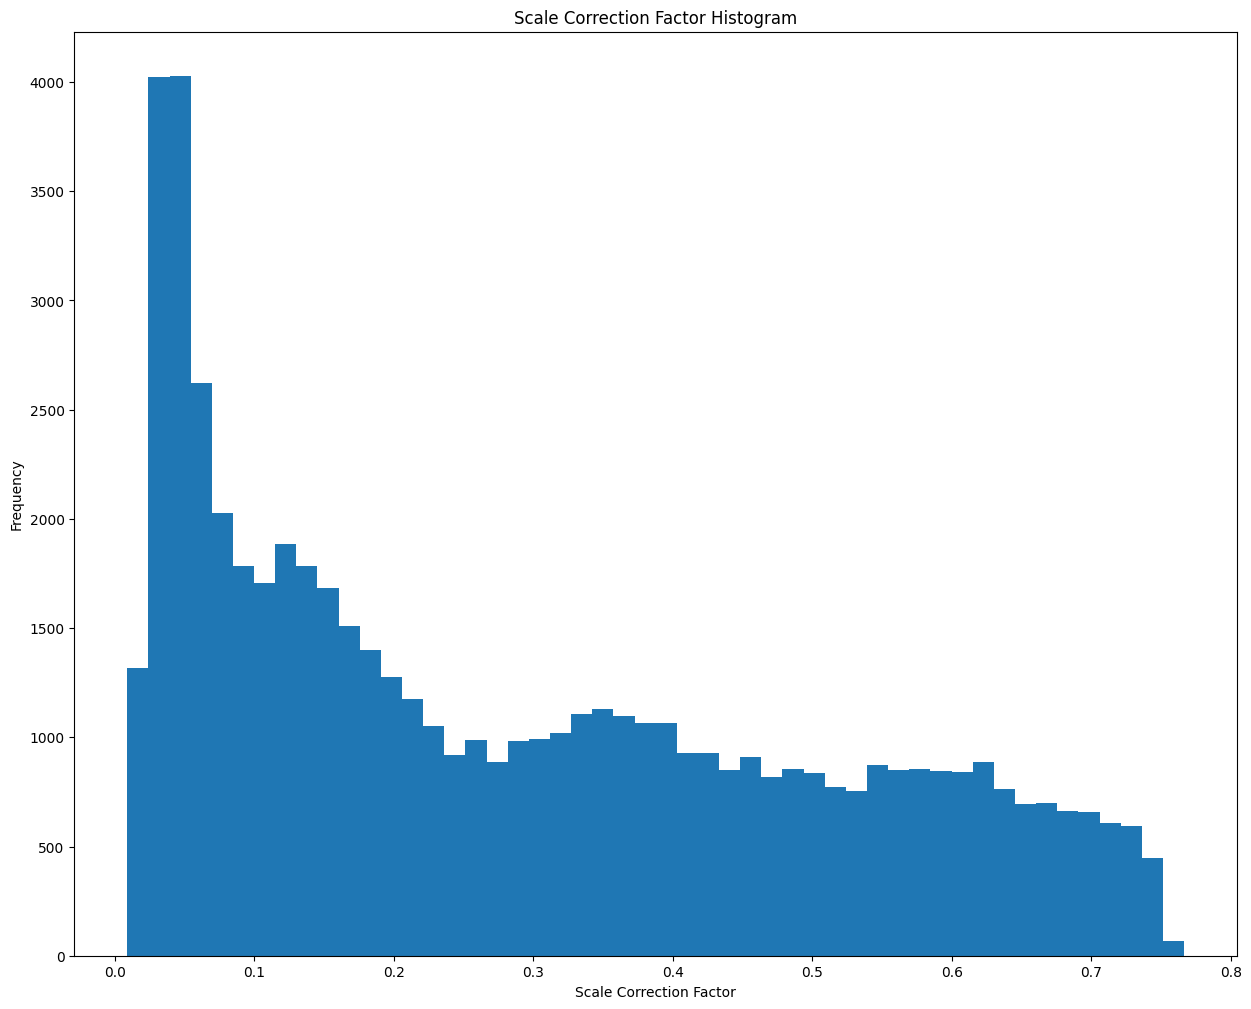

In [ ]:
scale_correction_factor = WS.scale_correction_factor

# show histogram of scale_correction_factor
plt.hist(scale_correction_factor.cpu().detach().numpy(), bins=50)
plt.title("Scale Correction Factor Histogram")
plt.xlabel("Scale Correction Factor")
plt.ylabel("Frequency")
plt.show()